In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("training_dataset_02_08.csv")

In [2]:
df.head()

,Unnamed: 0,MLSAreaMajor,Stories,ViewYN,NewConstructionYN,Levels,PoolPrivateYN,BuyerOfficeAOR,GarageSpaces,LotSizeAcres,...,PropertyType,MlsStatus,ParkingTotal,PropertySubType,CountyOrParish,BedroomsTotal,StateOrProvince,PurchaseContractDate,ContractStatusChangeDate,PostalCode
0,0,APPV - Apple Valley,1.0,False,False,Unknown,False,TriCounties,2.0,0.6428,...,Land,Closed,2.0,Unknown,San Bernardino,3.0,CA,2022-01-10,2025-02-21,92307
1,1,259 - Moreno Valley,1.0,False,False,Unknown,False,InlandValleys,2.0,0.9100,...,Land,Closed,2.0,Unknown,Riverside,3.0,CA,2024-11-08,2025-02-14,92553
2,2,91942 - La Mesa,1.0,False,False,One,False,PacificSouthwest,2.0,0.1674,...,Residential,Closed,6.0,SingleFamilyResidence,San Diego,4.0,CA,2021-01-25,2025-02-11,91942
3,3,91942 - La Mesa,1.0,False,False,One,False,SanDiego,2.0,0.1674,...,Residential,Closed,4.0,SingleFamilyResidence,San Diego,5.0,CA,2021-01-14,2025-02-14,91942
4,4,91942 - La Mesa,1.0,False,False,One,False,SanDiego,2.0,0.1674,...,Residential,Closed,4.0,SingleFamilyResidence,San Diego,4.0,CA,2021-01-25,2025-02-18,91942


In [3]:
print("Shape:", df.shape)

Shape: (111136, 38)


In [4]:
print("\nUnique values per column:\n", df.nunique())


Unique values per column:
 Unnamed: 0                  111136
MLSAreaMajor                  1030
Stories                          2
ViewYN                           2
NewConstructionYN                2
Levels                          19
PoolPrivateYN                    2
BuyerOfficeAOR                  62
GarageSpaces                    42
LotSizeAcres                 11805
LotSizeSquareFeet            22912
LotSizeArea                  22957
BuyerOfficeName              12082
BuyerAgentFirstName          11701
BuyerAgentMlsId              55314
StreetNumberNumeric          28801
UnparsedAddress             109686
City                           970
YearBuilt                      154
FireplaceYN                      2
BuyerAgentLastName           24185
LivingArea                    5650
Latitude                    103535
Longitude                   104816
BuyerAgentAOR                   54
BathroomsTotalInteger           41
ClosePrice                   10932
CloseDate                  

In [5]:
sns.set(style="whitegrid", palette="viridis", font_scale=1.0)
plt.rcParams["figure.figsize"] = (10, 6)

num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns

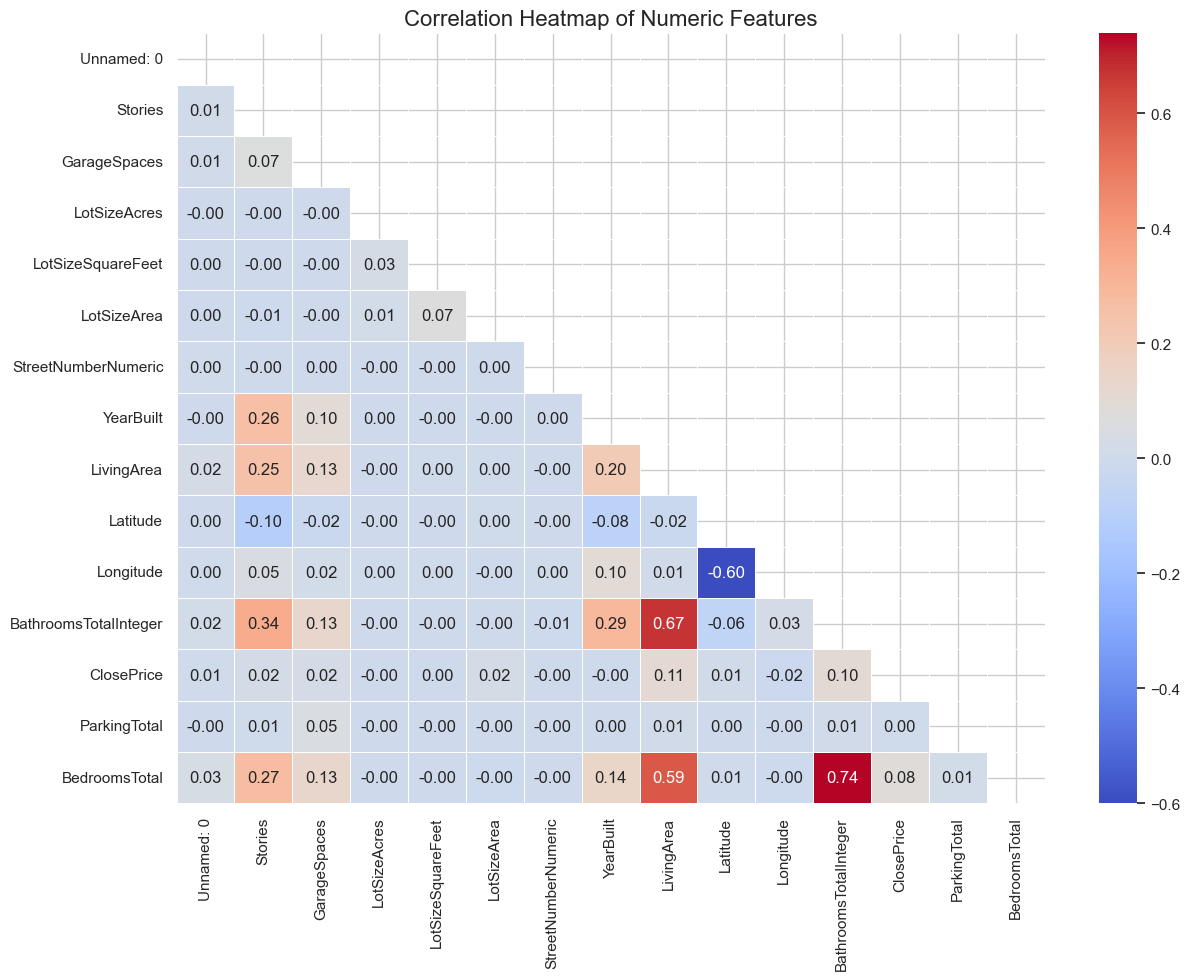

In [6]:
plt.figure(figsize=(14,10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features", fontsize=16)
plt.show()

Top correlated feature pairs:
 BedroomsTotal          BathroomsTotalInteger    0.739190
BathroomsTotalInteger  BedroomsTotal            0.739190
LivingArea             BathroomsTotalInteger    0.672744
BathroomsTotalInteger  LivingArea               0.672744
BedroomsTotal          LivingArea               0.592158
dtype: float64


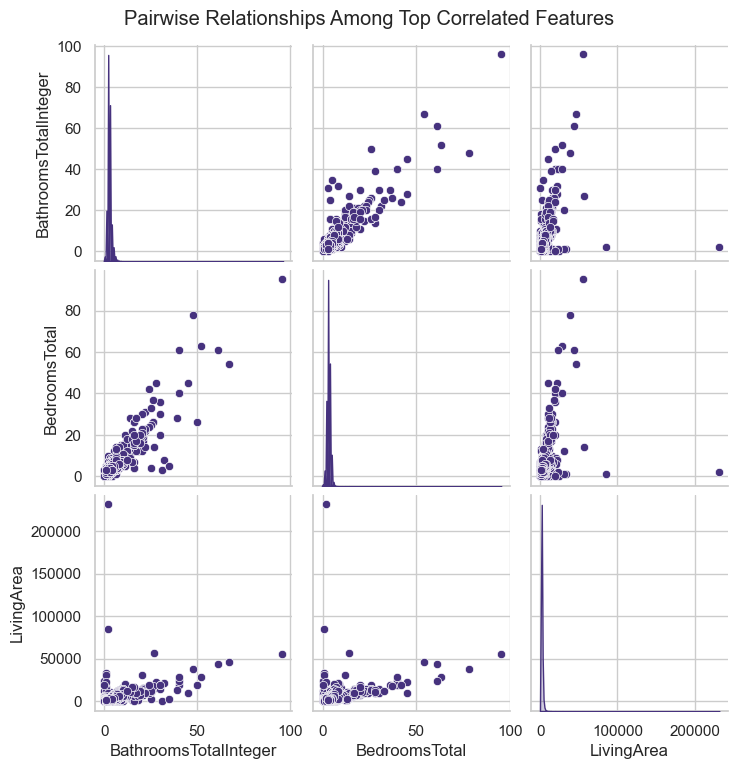

In [7]:
corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]  # remove self-correlation
top_pairs = corr_pairs.head(5)
print("Top correlated feature pairs:\n", top_pairs)


top_features = list(set([f for pair in top_pairs.index for f in pair]))
sns.pairplot(df[top_features], diag_kind="kde")
plt.suptitle("Pairwise Relationships Among Top Correlated Features", y=1.02)
plt.show()

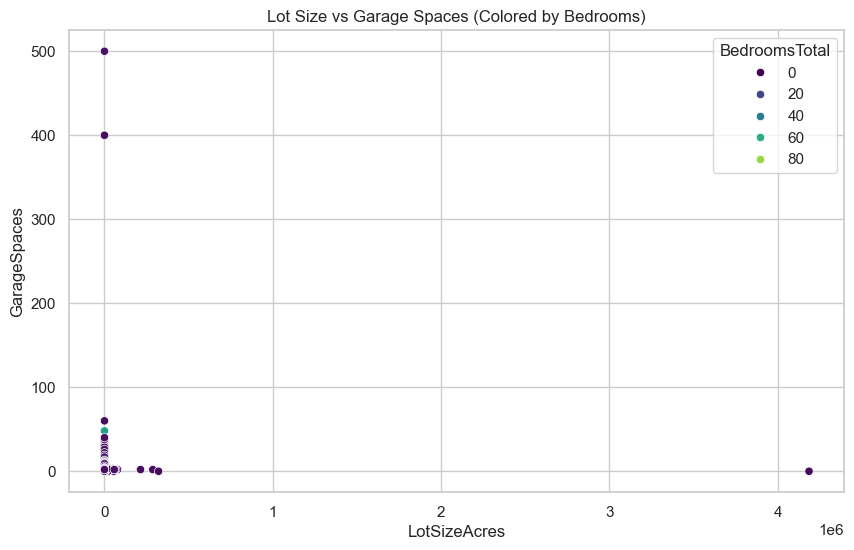

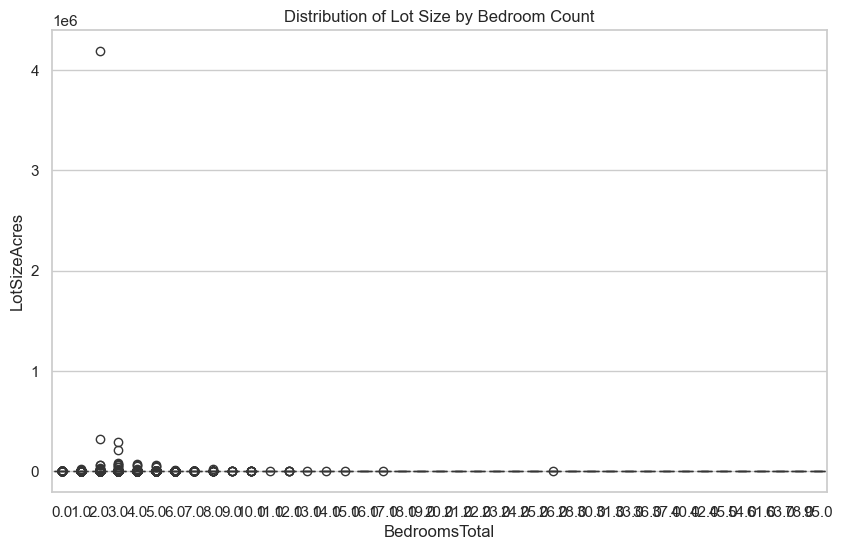

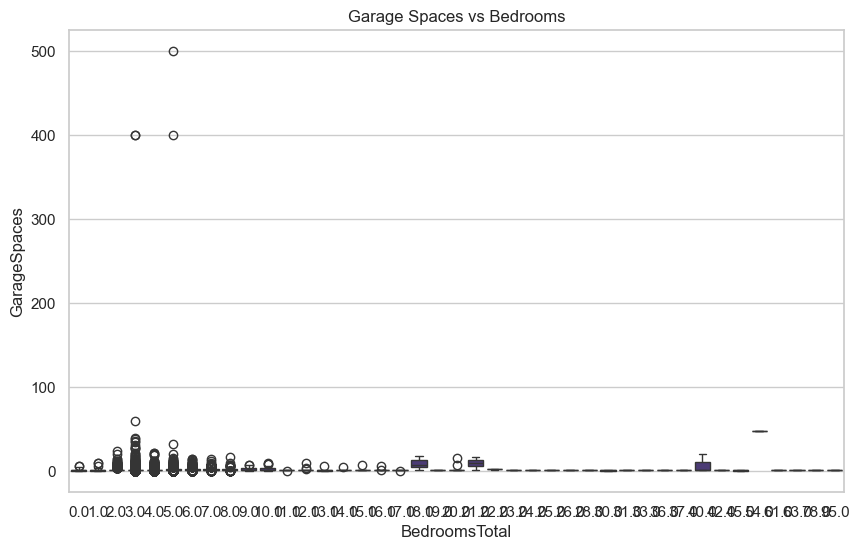

In [8]:
sns.scatterplot(data=df, x="LotSizeAcres", y="GarageSpaces", hue="BedroomsTotal", palette="viridis")
plt.title("Lot Size vs Garage Spaces (Colored by Bedrooms)")
plt.show()

sns.boxplot(data=df, x="BedroomsTotal", y="LotSizeAcres")
plt.title("Distribution of Lot Size by Bedroom Count")
plt.show()

sns.boxplot(data=df, x="BedroomsTotal", y="GarageSpaces")
plt.title("Garage Spaces vs Bedrooms")
plt.show()

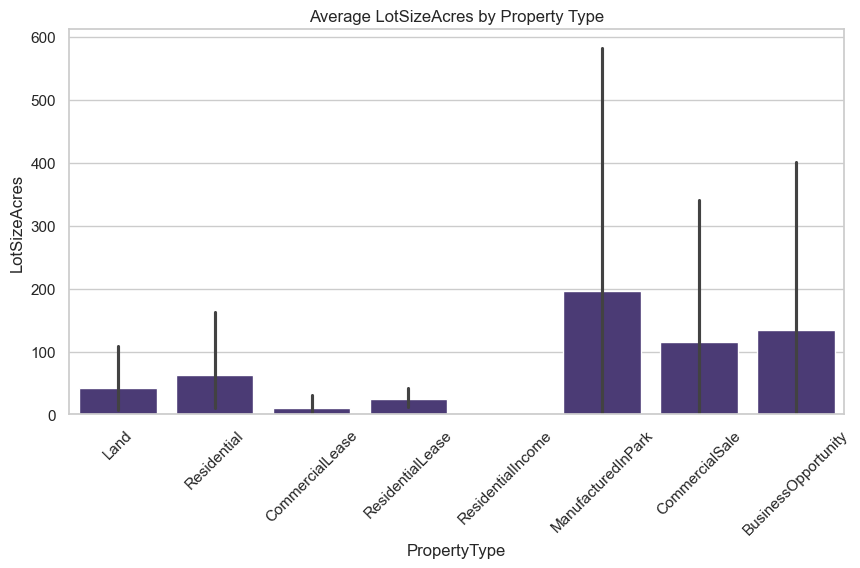

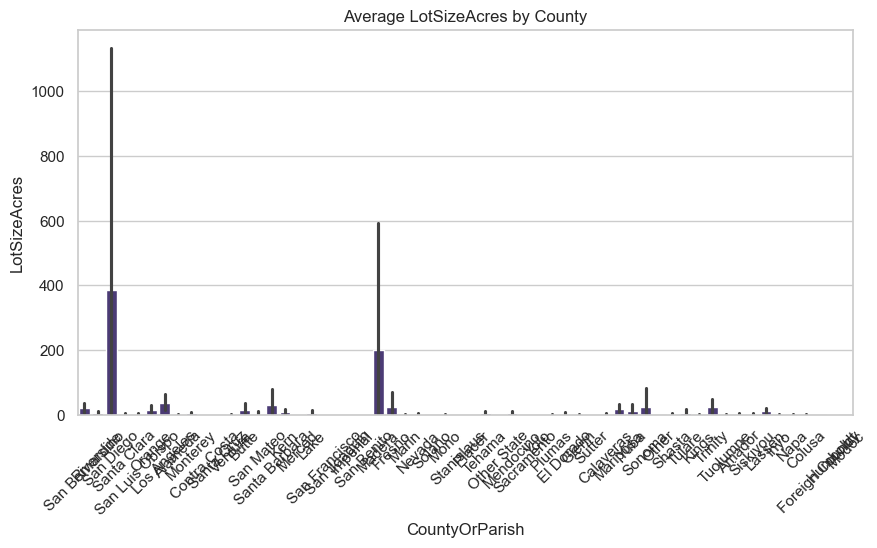

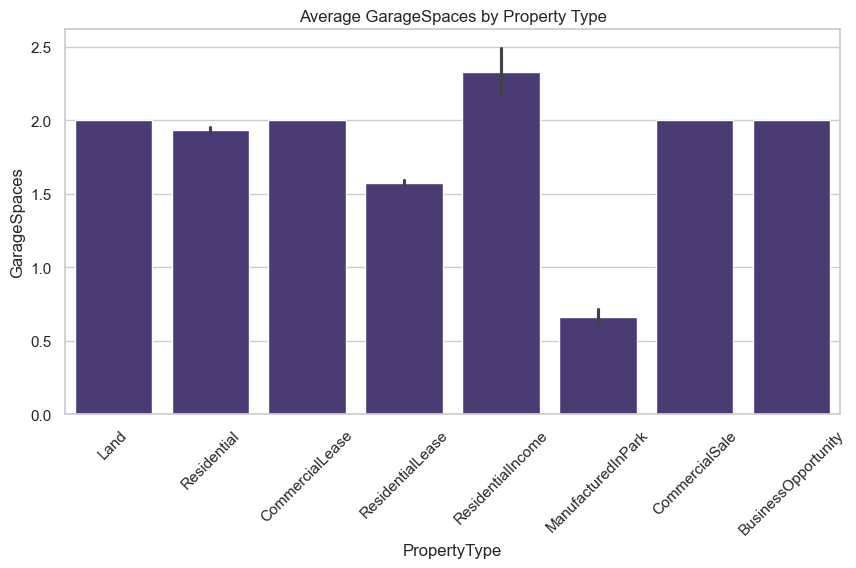

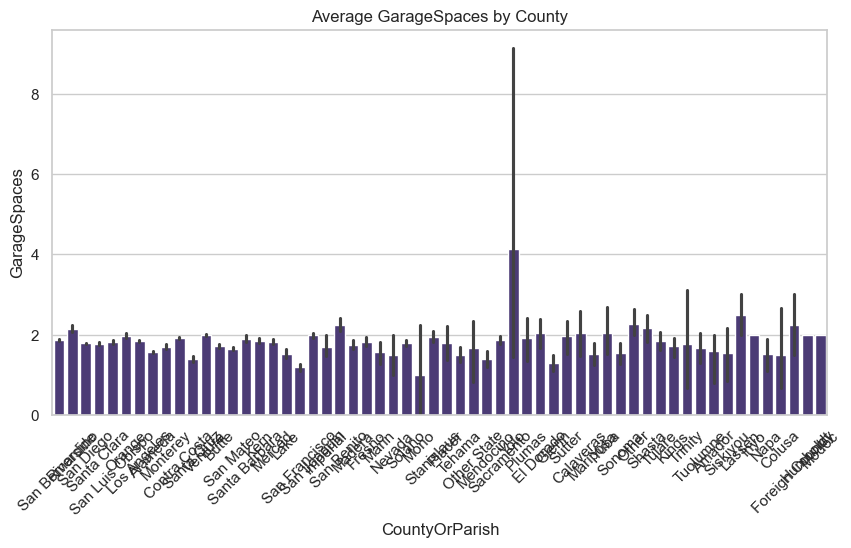

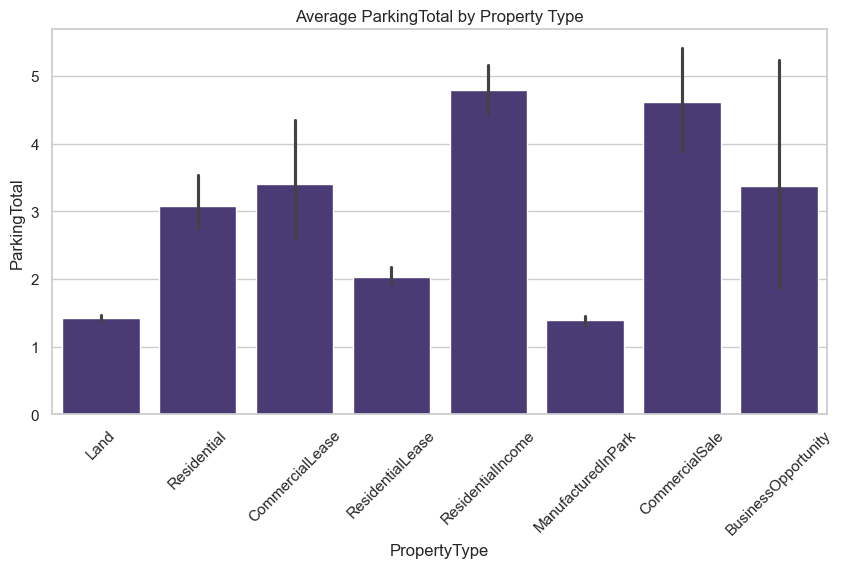

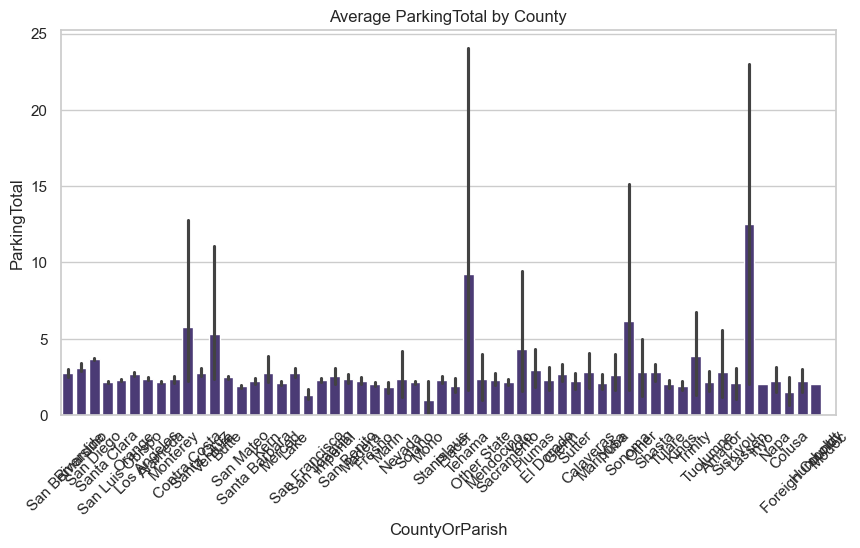

In [9]:
for col in ["LotSizeAcres", "GarageSpaces", "ParkingTotal"]:
    plt.figure(figsize=(10,5))
    sns.barplot(data=df, x="PropertyType", y=col, estimator=np.mean)
    plt.xticks(rotation=45)
    plt.title(f"Average {col} by Property Type")
    plt.show()

    plt.figure(figsize=(10,5))
    sns.barplot(data=df, x="CountyOrParish", y=col, estimator=np.mean)
    plt.xticks(rotation=45)
    plt.title(f"Average {col} by County")
    plt.show()

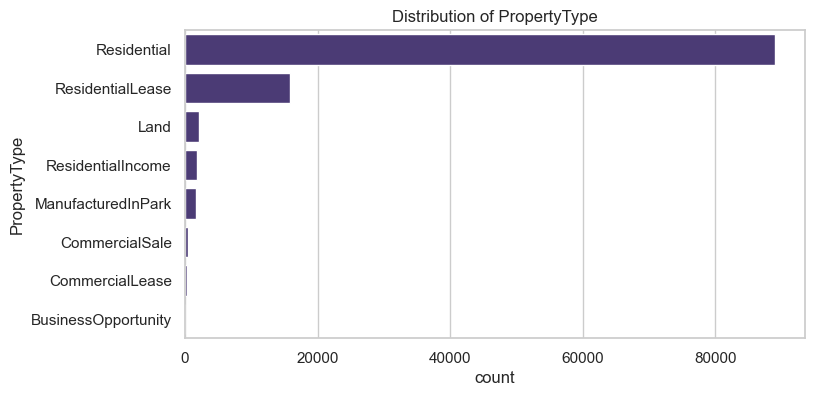

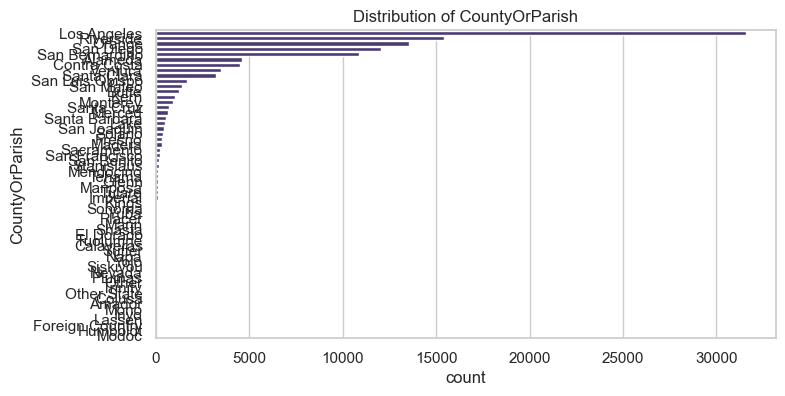

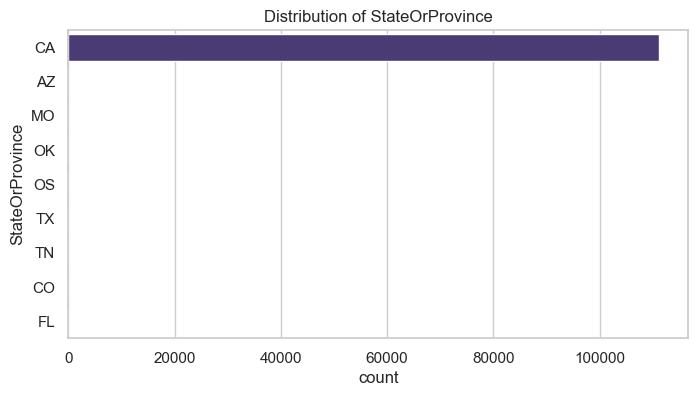

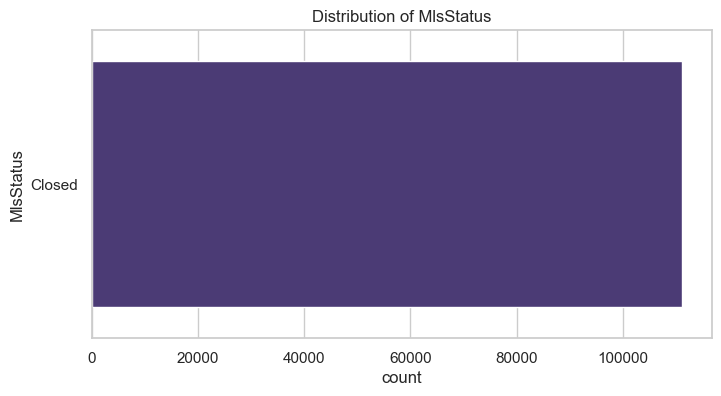

In [10]:
for col in ["PropertyType", "CountyOrParish", "StateOrProvince", "MlsStatus"]:
    plt.figure(figsize=(8,4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()

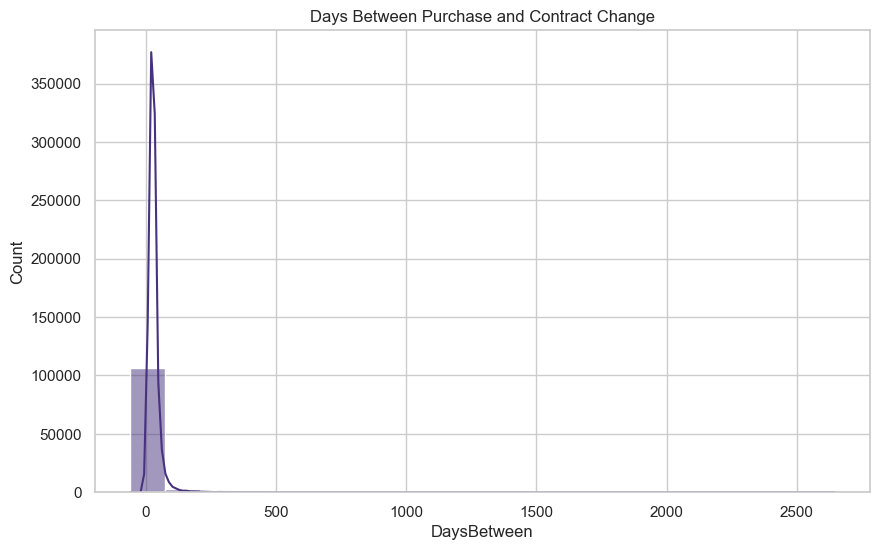

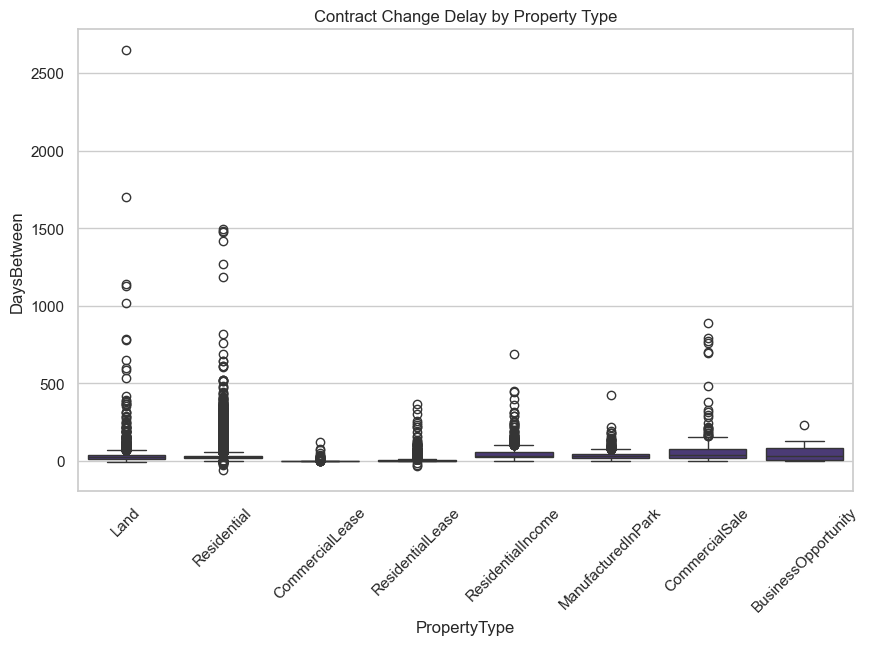

In [11]:
df["PurchaseContractDate"] = pd.to_datetime(df["PurchaseContractDate"], errors="coerce")
df["ContractStatusChangeDate"] = pd.to_datetime(df["ContractStatusChangeDate"], errors="coerce")

df["DaysBetween"] = (df["ContractStatusChangeDate"] - df["PurchaseContractDate"]).dt.days

sns.histplot(df["DaysBetween"], bins=20, kde=True)
plt.title("Days Between Purchase and Contract Change")
plt.show()

sns.boxplot(x="PropertyType", y="DaysBetween", data=df)
plt.title("Contract Change Delay by Property Type")
plt.xticks(rotation=45)
plt.show()

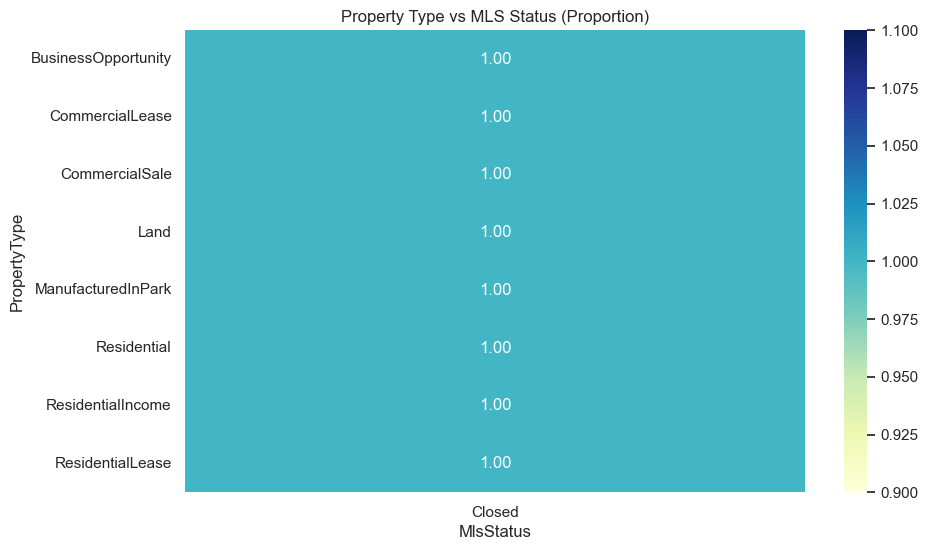

In [12]:
cross_tab = pd.crosstab(df["PropertyType"], df["MlsStatus"], normalize="index")
sns.heatmap(cross_tab, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Property Type vs MLS Status (Proportion)")
plt.show()

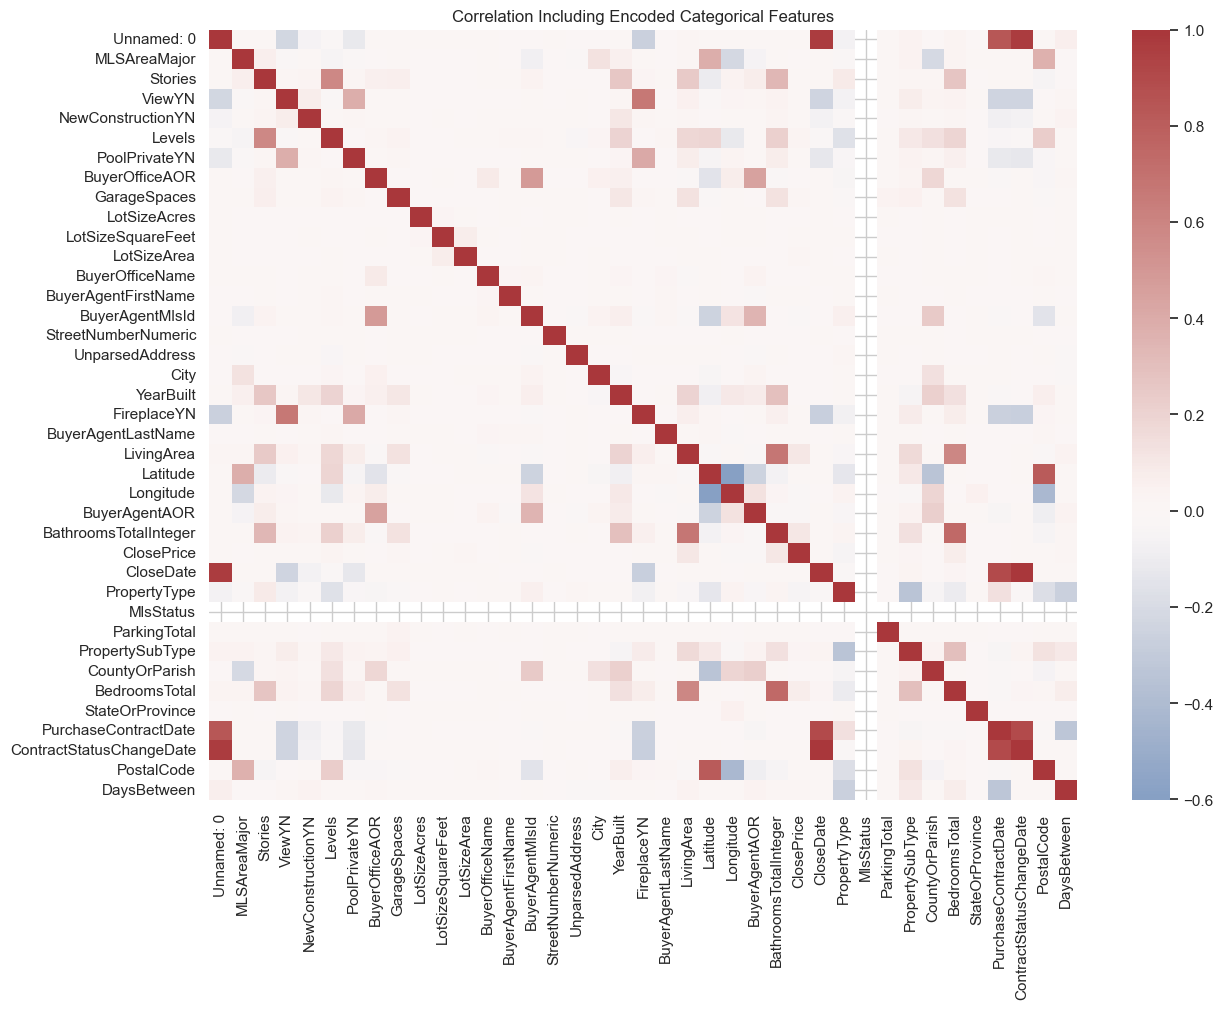

In [13]:
from sklearn.preprocessing import LabelEncoder

encoded = df.copy()
for col in cat_cols:
    encoded[col] = LabelEncoder().fit_transform(df[col].astype(str))

plt.figure(figsize=(14,10))
sns.heatmap(encoded.corr(), cmap="vlag", center=0)
plt.title("Correlation Including Encoded Categorical Features")
plt.show()